In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import time
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns

### Step 1: Data ingestion – import Hong Kong stock data via yfinance

In [3]:
# Ingest HK stock data via yfinance and group by industry
hk_stocks = [
    # ---  IT & Internet  ---
    '0700.HK', '3690.HK', '9988.HK', '1024.HK', '1810.HK', '9888.HK', '9618.HK', '9626.HK', '0772.HK', '0241.HK',
    '0268.HK', '0992.HK', '1347.HK', '0981.HK', '1357.HK', '2400.HK', '0522.HK', '2013.HK', '0020.HK', '0598.HK',
    '1797.HK', '1860.HK', '1980.HK', '2000.HK', '2121.HK', '2390.HK', '3067.HK', '6060.HK', '6088.HK', '6608.HK',
    '9898.HK', '9961.HK', '9999.HK', '0142.HK', '0807.HK', '0285.HK', '0552.HK', '0853.HK', '1270.HK',
    
    # ---  Financials: Banks, Insurance, Brokers  ---
    '0005.HK', '1299.HK', '0939.HK', '3988.HK', '1398.HK', '2318.HK', '2628.HK', '0388.HK', '2328.HK', '3968.HK',
    '1658.HK', '3328.HK', '1336.HK', '1395.HK', '0966.HK', '6030.HK', '3908.HK', '2611.HK', '1776.HK', '1963.HK', 
    '1988.HK', '2016.HK', '2199.HK', '2359.HK', '3319.HK', '3323.HK', '3606.HK', '6178.HK', '6199.HK', '6806.HK',
    '6818.HK', '6881.HK', '6886.HK', '0440.HK', '0626.HK', '1111.HK', '1551.HK',
    
    # ---  Real Estate & Property Management  ---
    '0016.HK', '1109.HK', '0688.HK', '0960.HK', '1113.HK', '1997.HK', '0823.HK', '1209.HK', '6098.HK', '3316.HK',
    '2669.HK', '0001.HK', '0101.HK', '0012.HK', '0017.HK', '0083.HK', '0123.HK', '0272.HK', '0435.HK', '0604.HK',
    '0813.HK', '0817.HK', '0884.HK', '1166.HK', '1196.HK', '1233.HK', '1628.HK', '1638.HK', '1777.HK', '1813.HK',
    '1918.HK', '1966.HK', '2007.HK', '2777.HK', '3333.HK', '3377.HK', '3383.HK', '3900.HK', '3990.HK',
    
    # ---  Consumer Discretionary & Staples  ---
    '3690.HK', '1211.HK', '2331.HK', '2020.HK', '1928.HK', '0175.HK', '0291.HK', '1876.HK', '0151.HK', '0288.HK',
    '2319.HK', '6618.HK', '2269.HK', '1880.HK', '9922.HK', '6862.HK', '9992.HK', '1112.HK', '0322.HK', '0551.HK',
    '0762.HK', '1044.HK', '1119.HK', '1316.HK', '1458.HK', '1579.HK', '1610.HK', '1833.HK', '1910.HK', '1930.HK',
    '2162.HK', '2313.HK', '6110.HK', '6186.HK', '9863.HK', '9866.HK', '9868.HK', '9901.HK', '9987.HK', '9990.HK',
    
    # ---  Healthcare & Biotech  ---
    '1093.HK', '1177.HK', '2269.HK', '1513.HK', '1801.HK', '3759.HK', '2160.HK', '0241.HK', '0460.HK', '0512.HK',
    '0570.HK', '0853.HK', '1302.HK', '1530.HK', '1548.HK', '1666.HK', '1672.HK', '1873.HK', '1951.HK', '2096.HK',
    '2169.HK', '2181.HK', '2186.HK', '2192.HK', '2196.HK', '2252.HK', '2273.HK', '2315.HK', '3320.HK', '3681.HK',
    '6160.HK', '6185.HK', '6606.HK', '6618.HK', '6633.HK', '6660.HK', '6826.HK', '6855.HK', '9926.HK', '9966.HK',
    
    # ---  Energy, Materials & Industrials  ---
    '0883.HK', '0857.HK', '0386.HK', '2899.HK', '1088.HK', '1898.HK', '1378.HK', '0914.HK', '3323.HK', '0066.HK',
    '0669.HK', '0135.HK', '0267.HK', '0358.HK', '0546.HK', '0743.HK', '0902.HK', '0916.HK', '0968.HK', '1033.HK',
    '1052.HK', '1066.HK', '1171.HK', '1216.HK', '1313.HK', '1787.HK', '1798.HK', '1816.HK', '1818.HK', '1919.HK',
    '2009.HK', '2038.HK', '2343.HK', '2386.HK', '2727.HK', '2883.HK', '3382.HK', '3898.HK', '3993.HK',
    
    # ---  Utilities, Telecoms & Others  ---
    '0941.HK', '0762.HK', '0728.HK', '0003.HK', '0006.HK', '1038.HK', '0836.HK', '0902.HK', '0916.HK', '1193.HK',
    '1359.HK', '1816.HK', '2380.HK', '2638.HK', '2688.HK', '3969.HK', '6033.HK', '6823.HK', '0002.HK', '0014.HK',
    '0270.HK', '0345.HK', '0392.HK', '0435.HK', '0590.HK', '0659.HK', '0694.HK', '0696.HK', '0753.HK', '1055.HK',
    '1083.HK', '1114.HK', '1186.HK', '1800.HK', '1882.HK', '1883.HK', '1929.HK', '1958.HK'
]

# Remove duplicate tickers and sort alphabetically
hk_stocks = sorted(list(set(hk_stocks)))
print(f"Successfully built stock pool, total: {len(hk_stocks)} stocks")

Successfully built stock pool, total: 261 stocks


In [4]:
# Fetch OHLCV Data
print(f"Downloading daily OHLCV data for {len(hk_stocks)} stocks")
raw_data = yf.download(hk_stocks, start='2022-01-01', end='2024-12-31', group_by='ticker', auto_adjust=True)

df_list = []
for ticker in hk_stocks:
    if ticker not in raw_data or raw_data[ticker].empty: continue
    temp = raw_data[ticker].copy()
    temp['Ticker'] = ticker
    temp['Turnover'] = temp['Close'] * temp['Volume']
    df_list.append(temp)

main_df = pd.concat(df_list).reset_index()
main_df = main_df.set_index(['Date', 'Ticker']).sort_index()

# Ingest market cap and industry info
print(f"Ingesting static metadata (Industry, Market Cap) for {len(hk_stocks)} stocks...")
meta_data = []
for i, ticker in enumerate(hk_stocks):
    try:
        tk = yf.Ticker(ticker)
        info = tk.info
        meta_data.append({
            'Ticker': ticker,
            'MarketCap': info.get('marketCap', np.nan),
            'Sector': info.get('sector', 'Unknown')
        })
        if i % 10 == 0: print(f"Progress: {i}/{len(hk_stocks)}")
        time.sleep(0.2)
    except:
        meta_data.append({'Ticker': ticker, 'MarketCap': np.nan, 'Sector': 'Unknown'})

df_meta = pd.DataFrame(meta_data).set_index('Ticker')
final_data = main_df.reset_index().merge(df_meta, on='Ticker', how='left').set_index(['Date', 'Ticker'])

[*********************100%***********************]  261 of 261 completed


Ingesting static metadata (Industry, Market Cap) for 261 stocks...
Progress: 0/261
Progress: 10/261
Progress: 20/261
Progress: 30/261
Progress: 40/261
Progress: 50/261
Progress: 60/261
Progress: 70/261
Progress: 80/261
Progress: 90/261
Progress: 100/261
Progress: 110/261
Progress: 120/261
Progress: 130/261
Progress: 140/261
Progress: 150/261
Progress: 160/261
Progress: 170/261
Progress: 180/261
Progress: 190/261
Progress: 200/261
Progress: 210/261
Progress: 220/261
Progress: 230/261
Progress: 240/261
Progress: 250/261
Progress: 260/261


### Step 2: Factor construction

In [6]:
def construct_factors(df):
    data = df[~df.index.duplicated(keep='first')].copy().sort_index()
    data['daily_return'] = data.groupby('Ticker')['Close'].pct_change()
    
    # Calculate rolling windows with apply
    data['factor_skew'] = data.groupby('Ticker')['daily_return'].apply(
        lambda x: x.rolling(window=20).skew()
    ).reset_index(level=0, drop=True)
    
    data['factor_momentum'] = data.groupby('Ticker')['Close'].pct_change(periods=20)
    
    # Avoid division by zero
    safe_mkt_cap = data['MarketCap'].replace(0, np.nan)
    data['daily_turnover_rate'] = data['Turnover'] / safe_mkt_cap
    data['factor_turnover'] = data.groupby('Ticker')['daily_turnover_rate'].apply(
        lambda x: x.rolling(window=20).mean()
    ).reset_index(level=0, drop=True)
    
    return data.dropna(subset=['factor_skew', 'factor_momentum', 'factor_turnover'])

# CRITICAL: Ensure factor construction executes without error and returns valid data
factor_data = construct_factors(final_data) 
print(f"Factors generated successfully. Sample size: {len(factor_data)}")

Factors generated successfully. Sample size: 184360


### Step3: Data preprocessing & cleaning

In [7]:
# Universe filter
def preprocess_pipeline(df):
    data = df.copy().sort_index()
    
    # Remove "penny stocks" (price < 0.5)
    mask_price = data['Close'] >= 0.5
    # Remove the bottom 20% stocks by turnover daily
    mask_liquidity = data.groupby('Date', group_keys=False).apply(
        lambda x: x['Turnover'] >= x['Turnover'].quantile(0.2)
    )
    data = data[mask_price & mask_liquidity].copy()
    
    factor_cols = ['factor_skew', 'factor_momentum', 'factor_turnover']

# Sectional processing
    def process_sectional_factors(section):
        for col in factor_cols:
            # MAD remove outliers
            median = section[col].median()
            mad = (section[col] - median).abs().median()
            section[col] = section[col].clip(median - 3 * mad, median + 3 * mad)
            # Z-score normalization
            std = section[col].std()
            section[col] = (section[col] - section[col].mean()) / (std if std != 0 else 1)
            # Fill missing values with 0
            section[col] = section[col].fillna(0)
        return section
    
    return data.groupby('Date', group_keys=False).apply(process_sectional_factors)

processed_factor_data = preprocess_pipeline(factor_data)
print(f"Preprocessing complete. Sample size: {len(processed_factor_data)}")

Preprocessing complete. Sample size: 146668


### Step 4: Factor neutralization

In [8]:
# Factor neutralization: remove size and industry effects (to extract residuals via WLS regression)
def neutralize_factors(df):
    data = df.copy().sort_index()
    # Fill missing industry labels to prevent regression failure
    data['Sector'] = data['Sector'].fillna('Unknown')
    factor_cols = ['factor_skew', 'factor_momentum', 'factor_turnover']
    
    neutralized_list = []
    print(f"Processing cross-sectional neutralization for {len(hk_stocks)} stocks")
    
    for date, group in data.groupby('Date'):
        # Cross-sectional processing: 'group' represents the data for all stocks on a specific trading day
        # Robustness check: skip dates with insufficient observations for industry neutralization
        if len(group) < 15: 
            continue

        # Create an independent copy to avoid SettingWithCopyWarning.
        group = group.copy()
        
        # Prepare independent variables (X): Log market cap and industry dummy variables
        log_mkt_cap = np.log(group['MarketCap'].replace(0, np.nan)).fillna(0)
        industry_dummies = pd.get_dummies(group['Sector'], drop_first=True)
        
        X = pd.concat([log_mkt_cap, industry_dummies], axis=1)
        X = sm.add_constant(X)
        
        # Define WLS weights: square root of market capitalization
        weights = np.sqrt(group['MarketCap'].fillna(group['MarketCap'].median()))

        # Iterate through factors and extract residuals from regression
        for col in factor_cols:
            try:
                # Apply WLS to remove size and industry biases
                model = sm.WLS(group[col], X.astype(float), weights=weights).fit()
                group[col] = model.resid
            except:
                # If regression fails (e.g., rank deficiency), fallback to zero or original value
                group[col] = 0

                
        neutralized_list.append(group)
    
    final_neutralized_data = pd.concat(neutralized_list)
    
    # Final post-neutralization standardization (Force 0 mean and 1 variance)
    def finalize_std(section):
        for col in factor_cols:
            std = section[col].std()
            section[col] = (section[col] - section[col].mean()) / (std if std != 0 else 1)
        return section
    
    final_neutralized_data = final_neutralized_data.groupby('Date', group_keys=False).apply(finalize_std)
    return final_neutralized_data

neutralized_factor_data = neutralize_factors(processed_factor_data)
print(f"Successfully neutralized! Sample size: {len(neutralized_factor_data)}")

Processing cross-sectional neutralization for 261 stocks
Successfully neutralized! Sample size: 146668


### Step5: Single-factor test

In [25]:
# IC/IR analysis and quintile backtest via cross-sectional factor grouping.
# Split into 5 groups by target factor value.
def factor_test(df, target_factor, n_groups=5):
    data = df.copy().sort_index()
    
    # Prepare forward returns (T+1)
    data['next_ret'] = data.groupby('Ticker')['daily_return'].shift(-1)
    data = data.dropna(subset=['next_ret'])

    # IC/RankIC and IR statistics
    print(f"Processing IC/IR analysis: {target_factor}")

    # Calculate daily Pearson IC and Spearman RankIC
    ic_series = data.groupby('Date').apply(lambda x: x[target_factor].corr(x['next_ret']))
    rank_ic_series = data.groupby('Date').apply(lambda x: x[target_factor].corr(x['next_ret'], method='spearman'))
    
    # Calculate target statistics
    ic_mean = rank_ic_series.mean()
    ic_std = rank_ic_series.std()
    ir = ic_mean / ic_std if ic_std != 0 else 0
    ic_hit_rate = (rank_ic_series > 0).sum() / len(rank_ic_series) # Percentage of positive IC
    t_stat, p_value = stats.ttest_1samp(rank_ic_series, 0) # T-test on RankIC
    
    ic_summary = {
        'Factor': target_factor,
        'IC Mean': ic_series.mean(),
        'RankIC Mean': ic_mean,
        'IC Std': ic_std,
        'IR (Information Ratio)': ir,
        'IC > 0 Rate': ic_hit_rate,
        'IC T-Stat': t_stat,
        'IC P-Value': p_value
    }

    # Quantile backtest (5 quintiles)
    print(f"Performing 5-group stratified backtest for {target_factor}...")

    # Categorize stocks into 5 quintile groups cross-sectionally
    data['group'] = data.groupby('Date')[target_factor].transform(
        lambda x: pd.qcut(x, n_groups, labels=False, duplicates='drop')
    )
    
    # Calculate daily mean returns (t + 1) for each group
    group_ret = data.groupby(['Date', 'group'])['next_ret'].mean().unstack()
    
    # Calculate cumulative NAV for each group
    cum_group_ret = (1 + group_ret).cumprod()
    
    # Long-Short = group_1 - group_5
    ls_daily_ret = group_ret[0] - group_ret[n_groups-1]
    cum_ls_ret = (1 + ls_daily_ret).cumprod()
    
    # Calculate stratified metrics: annualized return
    annual_ret = group_ret.mean() * 252
    
    return ic_summary, rank_ic_series, cum_group_ret, cum_ls_ret, annual_ret

Processing IC/IR analysis: factor_turnover
Performing 5-group stratified backtest for factor_turnover...

==================== Turnover Factor IC/IR Statistics Summary ====================
Factor: factor_turnover
IC Mean: -0.0321
RankIC Mean: -0.0419
IC Std: 0.1590
IR (Information Ratio): -0.2635
IC > 0 Rate: 0.3787
IC T-Stat: -7.0367
IC P-Value: 0.0000


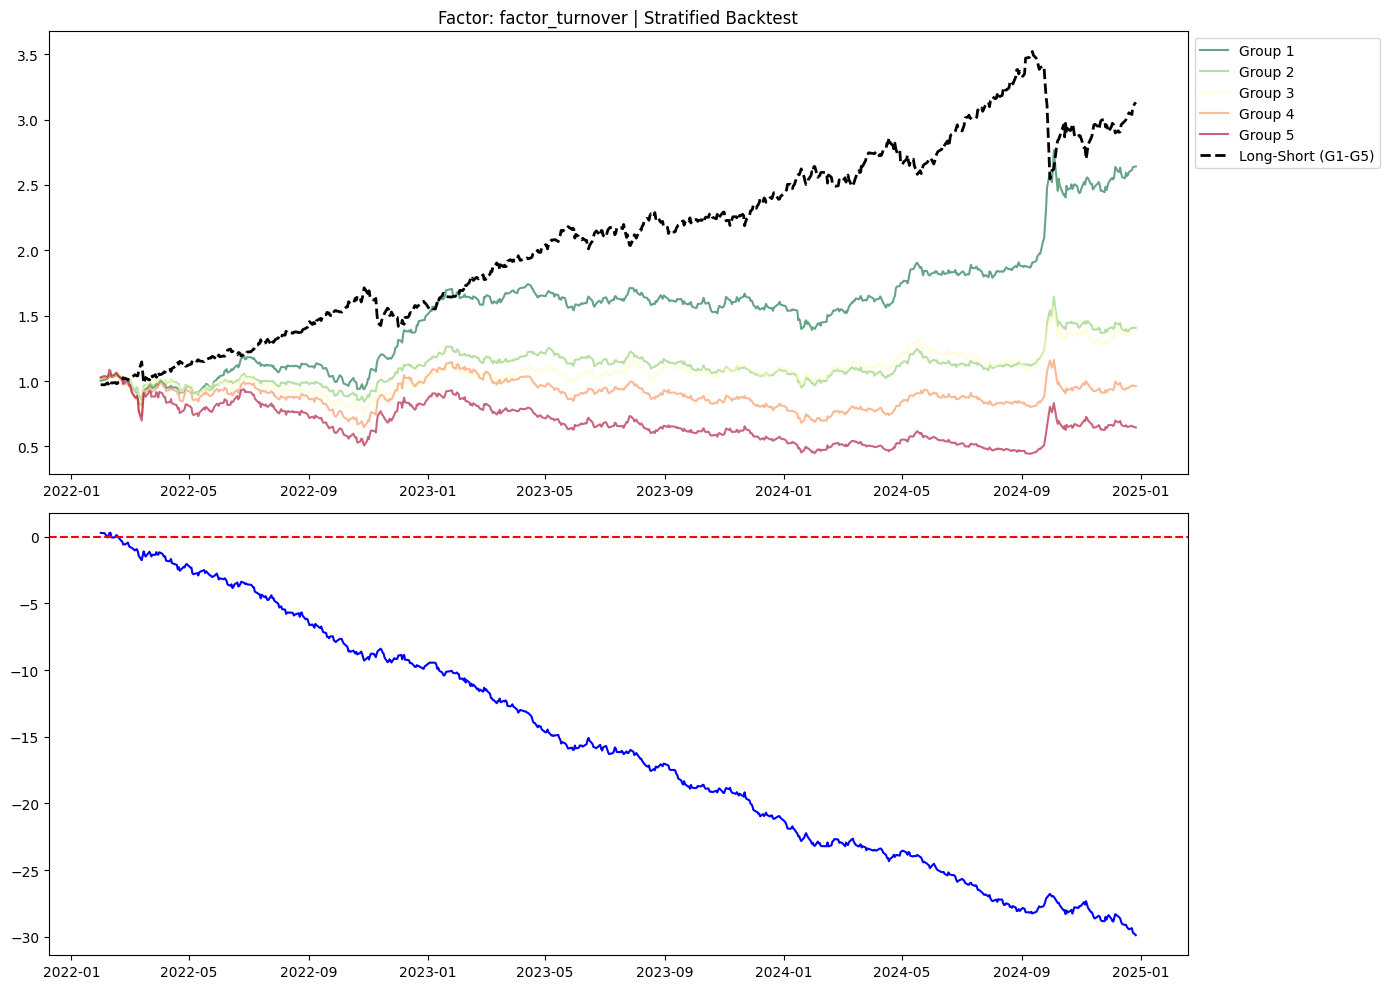


==================== factor_turnover Annualized Return by Quintile ====================
       Annualized Return
group                   
0               0.373882
1               0.149780
2               0.146263
3               0.042093
4              -0.060598


In [26]:
# Exec & viz: turnover factor
ic_stat1, daily_ic1, cum_g1, cum_ls1, ann1 = factor_test(
    neutralized_factor_data, target_factor='factor_turnover', n_groups=5
)

print("\n" + "="*20 + " Turnover Factor IC/IR Statistics Summary " + "="*20)
for k, v in ic_stat1.items():
    print(f"{k}: {v}") if isinstance(v, str) else print(f"{k}: {v:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, 5))
for i in range(5):
    axes[0].plot(cum_g1[i], label=f'Group {i+1}', color=colors[i], alpha=0.6)
axes[0].plot(cum_ls1, label='Long-Short (G1-G5)', color='black', linewidth=2, linestyle='--')
axes[0].set_title('Factor: factor_turnover | Stratified Backtest')
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].plot(daily_ic1.cumsum(), color='blue', label='Cumulative RankIC')
axes[1].axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

print("\n" + "="*20 + " factor_turnover Annualized Return by Quintile " + "="*20)
print(pd.DataFrame(ann1, columns=['Annualized Return']))


Processing IC/IR analysis: factor_momentum
Performing 5-group stratified backtest for factor_momentum...

==================== Momentum Factor IC/IR Statistics Summary ====================
Factor: factor_momentum
IC Mean: -0.0012
RankIC Mean: -0.0035
IC Std: 0.1558
IR (Information Ratio): -0.0223
IC > 0 Rate: 0.5077
IC T-Stat: -0.5955
IC P-Value: 0.5517


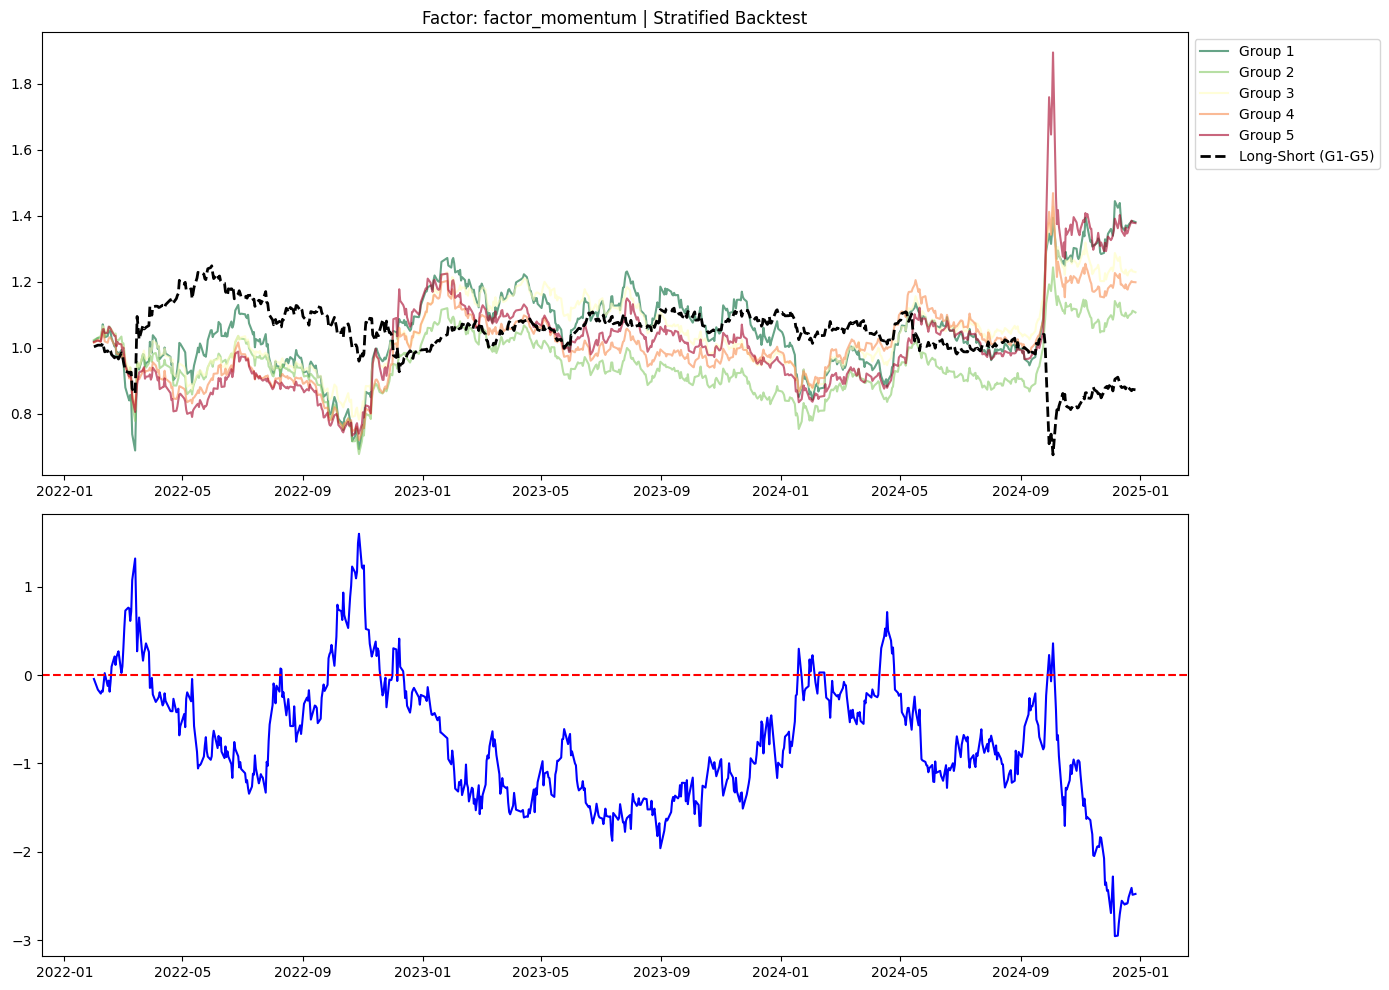


==================== factor_momentum Annualized Return by Quintile ====================
       Annualized Return
group                   
0               0.181530
1               0.076396
2               0.106955
3               0.101185
4               0.185286


In [27]:
# Exec & viz:  momentum factor
ic_stat2, daily_ic2, cum_g2, cum_ls2, ann2 = factor_test(
    neutralized_factor_data, target_factor='factor_momentum', n_groups=5
)

print("\n" + "="*20 + " Momentum Factor IC/IR Statistics Summary " + "="*20)
for k, v in ic_stat2.items():
    print(f"{k}: {v}") if isinstance(v, str) else print(f"{k}: {v:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for i in range(5):
    axes[0].plot(cum_g2[i], label=f'Group {i+1}', color=colors[i], alpha=0.6)
axes[0].plot(cum_ls2, label='Long-Short (G1-G5)', color='black', linewidth=2, linestyle='--')
axes[0].set_title('Factor: factor_momentum | Stratified Backtest')
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].plot(daily_ic2.cumsum(), color='blue', label='Cumulative RankIC')
axes[1].axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

print("\n" + "="*20 + " factor_momentum Annualized Return by Quintile " + "="*20)
print(pd.DataFrame(ann2, columns=['Annualized Return']))

Processing IC/IR analysis: factor_skew
Performing 5-group stratified backtest for factor_skew...

==================== Skewness Factor IC/IR Statistics Summary ====================
Factor: factor_skew
IC Mean: 0.0011
RankIC Mean: -0.0064
IC Std: 0.0967
IR (Information Ratio): -0.0666
IC > 0 Rate: 0.4614
IC T-Stat: -1.7775
IC P-Value: 0.0759


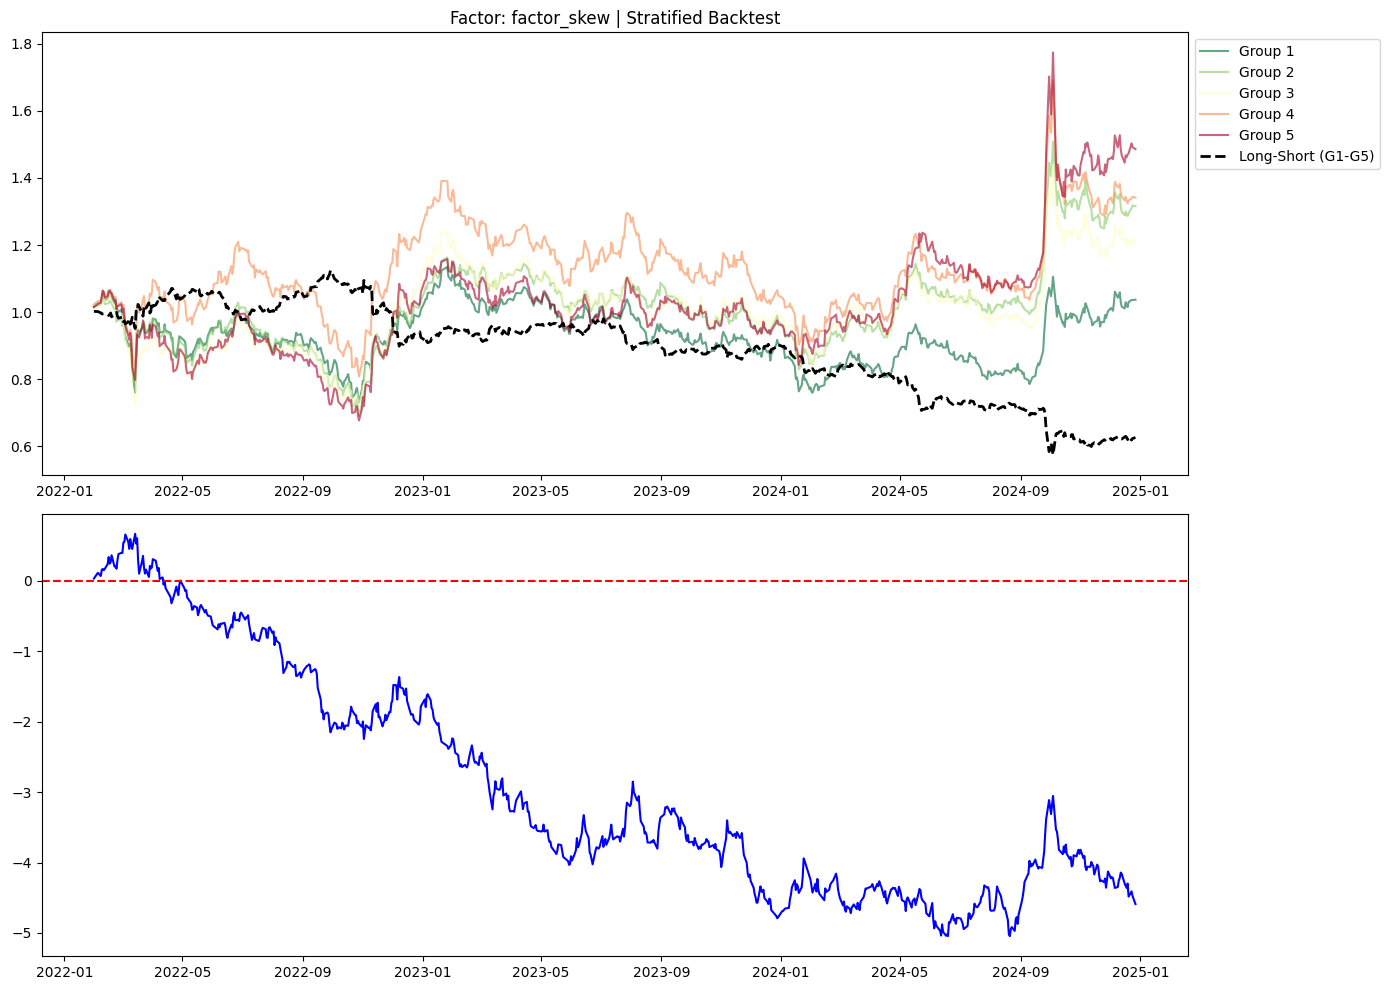


==================== factor_skew Annualized Return by Quintile ====================
       Annualized Return
group                   
0               0.050420
1               0.137893
2               0.110174
3               0.154415
4               0.200668


In [28]:
# Exec & viz: skewness factor
ic_stat3, daily_ic3, cum_g3, cum_ls3, ann3 = factor_test(
    neutralized_factor_data, target_factor='factor_skew', n_groups=5
)

print("\n" + "="*20 + " Skewness Factor IC/IR Statistics Summary " + "="*20)
for k, v in ic_stat3.items():
    print(f"{k}: {v}") if isinstance(v, str) else print(f"{k}: {v:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for i in range(5):
    axes[0].plot(cum_g3[i], label=f'Group {i+1}', color=colors[i], alpha=0.6)
axes[0].plot(cum_ls3, label='Long-Short (G1-G5)', color='black', linewidth=2, linestyle='--')
axes[0].set_title('Factor: factor_skew | Stratified Backtest')
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].plot(daily_ic3.cumsum(), color='blue', label='Cumulative RankIC')
axes[1].axhline(0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

print("\n" + "="*20 + " factor_skew Annualized Return by Quintile " + "="*20)
print(pd.DataFrame(ann3, columns=['Annualized Return']))

### Step 6: Multi-factor correlation analysis

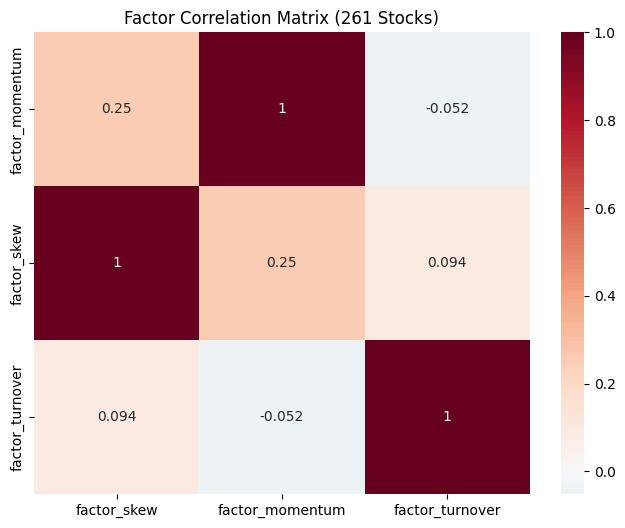

In [30]:
def analyze_factor_correlation(df):
    factor_cols = ['factor_skew', 'factor_momentum', 'factor_turnover']
    # Calculate mean cross-sectional correlation matrix.
    avg_corr = df.groupby('Date')[factor_cols].apply(lambda x: x.corr(method='spearman')).groupby(level=1).mean()
    return avg_corr[factor_cols]

corr_matrix = analyze_factor_correlation(neutralized_factor_data)
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('Factor Correlation Matrix (261 Stocks)')
plt.show()

### Step 7: Fama-MacBeth regression analysis

In [31]:
def fama_macbeth_test(df):
    data = df.copy().sort_index()
    factor_cols = ['factor_skew', 'factor_momentum', 'factor_turnover']
    data['next_ret'] = data.groupby('Ticker')['daily_return'].shift(-1)
    data = data.dropna(subset=['next_ret'])
    
    results = []
    for date, group in data.groupby('Date'):
        if len(group) < 10: continue
        X = sm.add_constant(group[factor_cols])
        y = group['next_ret']
        weights = np.sqrt(group['MarketCap'].fillna(group['MarketCap'].median()))
        res = sm.WLS(y, X.astype(float), weights=weights).fit()
        results.append({'Date': date, **res.params[factor_cols], 
                        **{f't_{c}': res.tvalues[c] for c in factor_cols}})
    
    res_df = pd.DataFrame(results).set_index('Date')
    
    # Compute performance metrics.
    eval_df = pd.DataFrame()
    for col in factor_cols:
        t_col = f't_{col}'
        eval_df.loc[col, '|t| Mean'] = res_df[t_col].abs().mean()
        eval_df.loc[col, '|t|>2 Rate'] = (res_df[t_col].abs() > 2).mean()
        eval_df.loc[col, 'Factor Return Mean'] = res_df[col].mean()
        eval_df.loc[col, 'Factor T-Stat'] = res_df[col].mean() / res_df[col].std() * np.sqrt(len(res_df))
        
    return eval_df, res_df[factor_cols]

eval_results, daily_returns = fama_macbeth_test(neutralized_factor_data)
print("\n" + "="*20 + " Fama-MacBeth Statistcs Summary with 261 Stocks " + "="*20)
print(eval_results.round(4))


==================== Fama-MacBeth Statistcs Summary with 261 Stocks ====================
                 |t| Mean  |t|>2 Rate  Factor Return Mean  Factor T-Stat
factor_skew        1.0777      0.1276              0.0001         0.9912
factor_momentum    1.6630      0.3100             -0.0001        -0.6702
factor_turnover    1.5649      0.3170             -0.0006        -4.0800
